# Informe de Evaluación: Impacto de Épocas Offline en Entrenamiento Distribuido
**Informe Final de Aprendizaje Profundo — Ingeniería en Informática — FIUBA**

**Autor:** Marcos Bianchi<br>
**Padrón:** 108921<br>
**Fecha:** Julio 2026<br>


### Configuración del Entorno de Evaluación

| Categoría | Parámetro | Valores Evaluados |
| :--- | :--- | :--- |
| **Modelo y Datos** | Dataset | MNIST (Full) |
| | Arquitectura de Red | LeNet-5 |
| | Función de Pérdida | Entropía Cruzada |
| **Optimización** | Optimizador | Adam ($\alpha = 0.01, \beta_1 = 0.9, \beta_2 = 0.999, \epsilon = 10^{-8}$) |
| | Tamaño de Mini-Batch | 64 |
| | Épocas de Entrenamiento | 48 totales por nodo |
| **Infraestructura** | Serialización | Sparse ($r = 0.5$) |
| **Variables Libres** | Algoritmo Distribuido | All-Reduce, Parameter Server (Sincrónico/Bloqueante) |
| | Escala del Cluster ($N$) | 6, 8, 10 nodos |
| | Épocas Offline ($\tau$) | 0, 2, 4 épocas offline |

### Especificación de la Infraestructura de Hardware

| Categoría | Componente | Especificación Técnica / Detalle |
| :--- | :--- | :--- |
| **Procesador (CPU)** | Modelo | Intel Core i5-8350U |
| | Arquitectura | x86_64 |
| | Núcleos Físicos | 4 |
| | Hilos Lógicos (Threads) | 8 |
| | Frecuencia de Reloj | Base: 1.7 GHz \| Turbo: 3.6 GHz |
| **Memoria** | Capacidad Total RAM | 8 GB |
| | Tipo y Velocidad | DDR4 @ 2400 MHz |
| **Entorno de Software** | Sistema Operativo | Ubuntu 24.04 LTS |
| | Entorno de Ejecución | Docker 29.6.1 \| Rust 1.96.1 \| CPython 3.14.0 |

In [1]:
from utils.measurement import measure_training_results


MEASUREMENTS = measure_training_results()

ALGORITHMS = sorted({ms.algorithm for ms in MEASUREMENTS})
NODES = sorted({ms.nodes for ms in MEASUREMENTS})
OFFLINE_EPOCHS = sorted({ms.offline_epochs for ms in MEASUREMENTS})

In [2]:
import matplotlib.pyplot as plt


# Assign a common colormap for all the plots into a COLORS list.
cmap = plt.get_cmap("Set2")
COLORS = [cmap(i % cmap.N) for i in range(cmap.N)]

# Assign common matplotlib parameters.
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#CBCBCB'
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.linewidth'] = 0.8

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt


def save_and_plot(name: str, plot_name: str) -> None:
    """
    Saves a plot to disk into the plots directory.
    """
    name_dir = Path("plots") / name
    name_dir.mkdir(parents=True, exist_ok=True)
    file_path = name_dir / plot_name

    plt.tight_layout()
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


In [4]:
from typing import Iterable, Optional, Generator
from collections.abc import Collection


def measurements_if(
    algorithm: Optional[str | Iterable[str]] = None,
    nodes: Optional[int | Iterable[int]] = None,
    offline_epochs: Optional[int | Iterable[int]] = None,
) -> list[Measurement]:
    """
    Helper function to retrieve the wanted measurements from the global measurements list.
    """
    def to_set(val: Any) -> Any:
        if val is None:
            return None

        if isinstance(val, Collection) and not isinstance(val, str):
            return set(val)
        
        return {val}

    filtered = MEASUREMENTS

    algorithm = to_set(algorithm)
    if algorithm is not None:
        filtered = (ms for ms in filtered if ms.algorithm in algorithm)

    nodes = to_set(nodes)
    if nodes is not None:
        filtered = (ms for ms in filtered if ms.nodes in nodes)

    offline_epochs = to_set(offline_epochs)
    if offline_epochs is not None:
        filtered = (ms for ms in filtered if ms.offline_epochs in offline_epochs)

    return list(filtered)


## Tiempos de ejecución para cada cantidad de Épocas Offline

Gráficos que muestran el tiempo que tomó cada uno de los entrenamientos en finalizar con algoritmos y cantidad de nodos distintos.

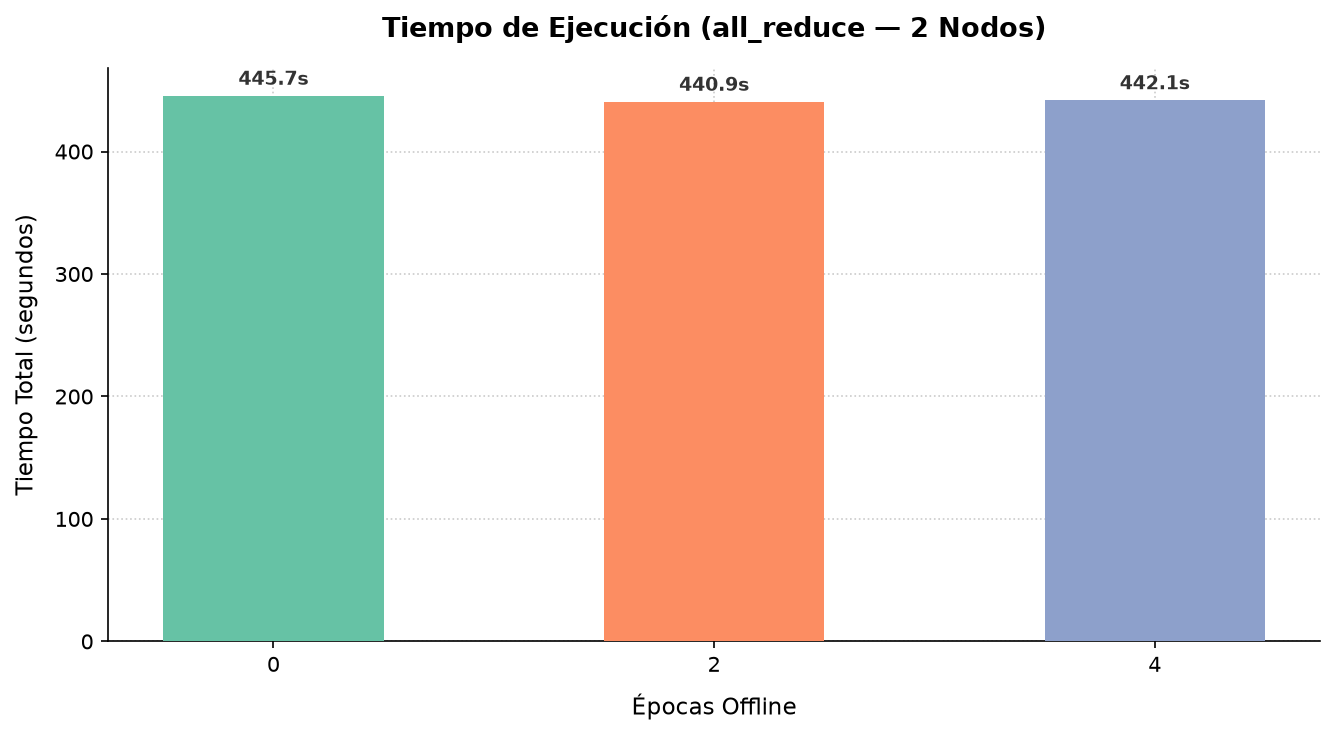

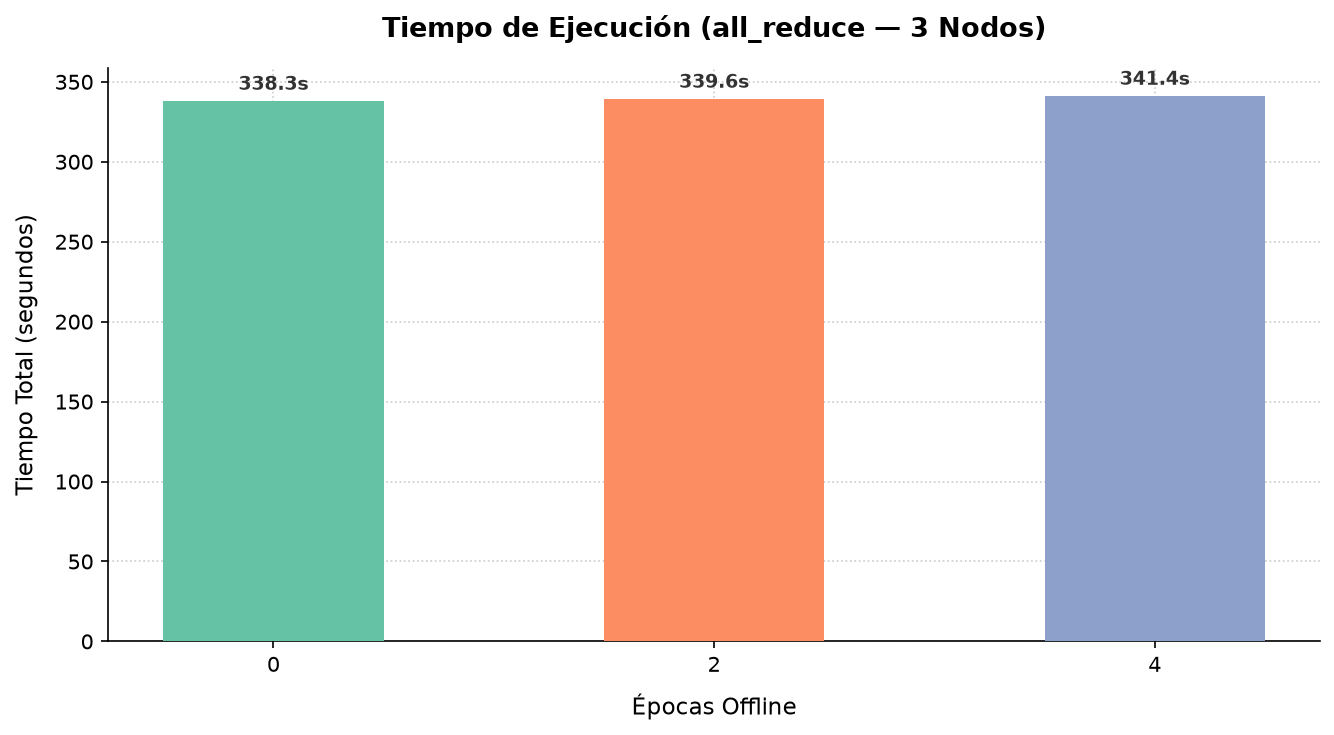

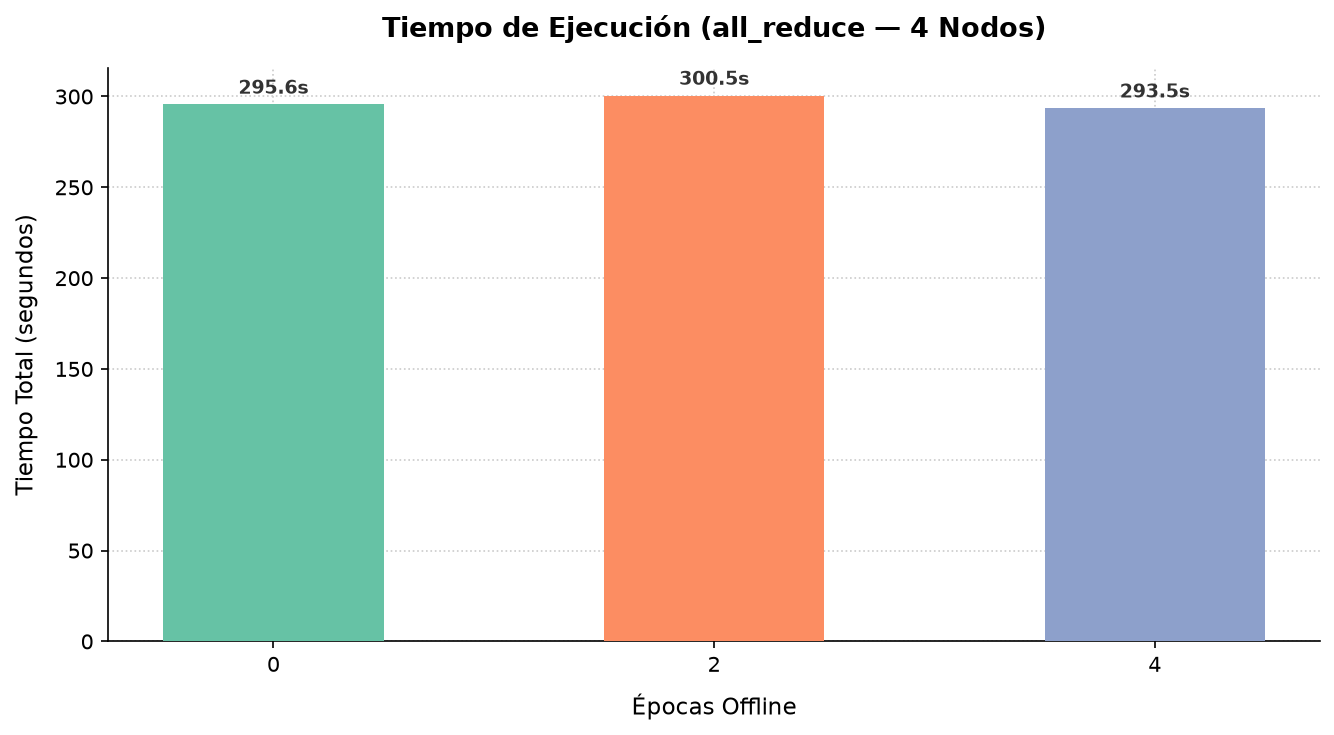

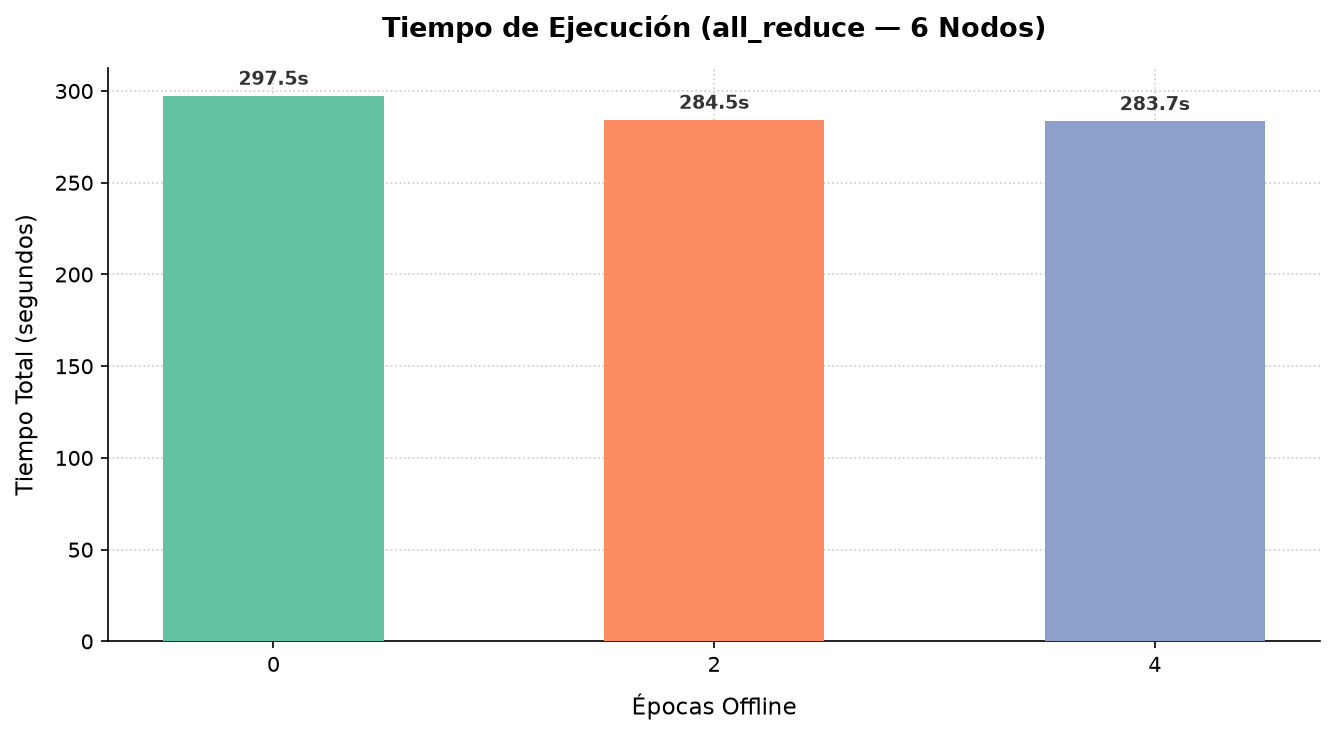

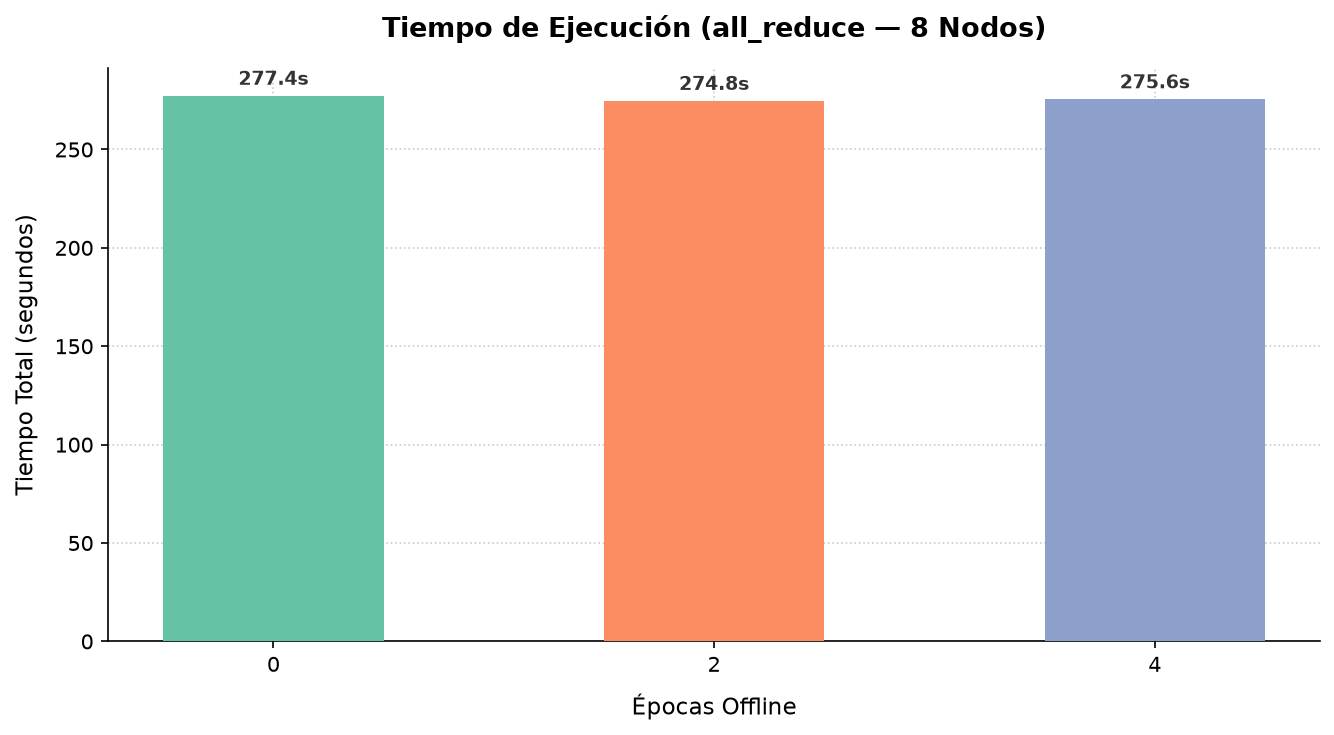

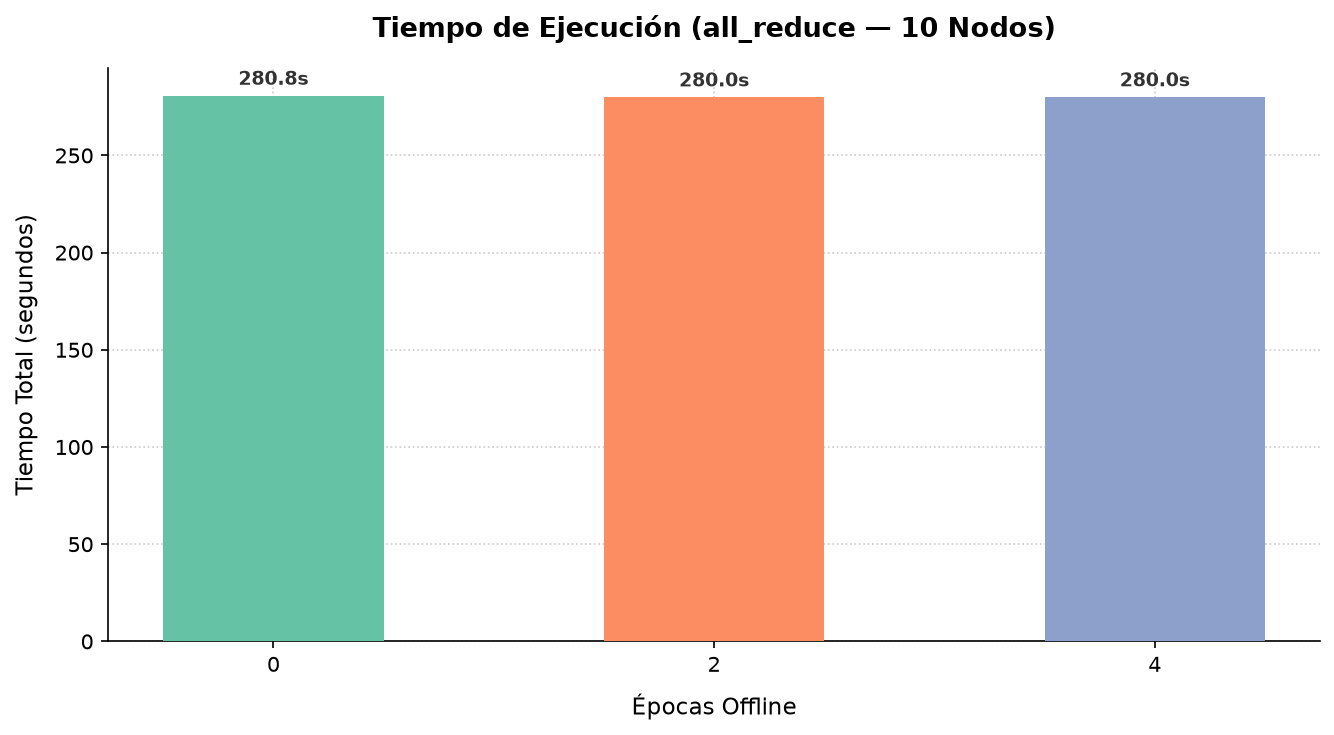

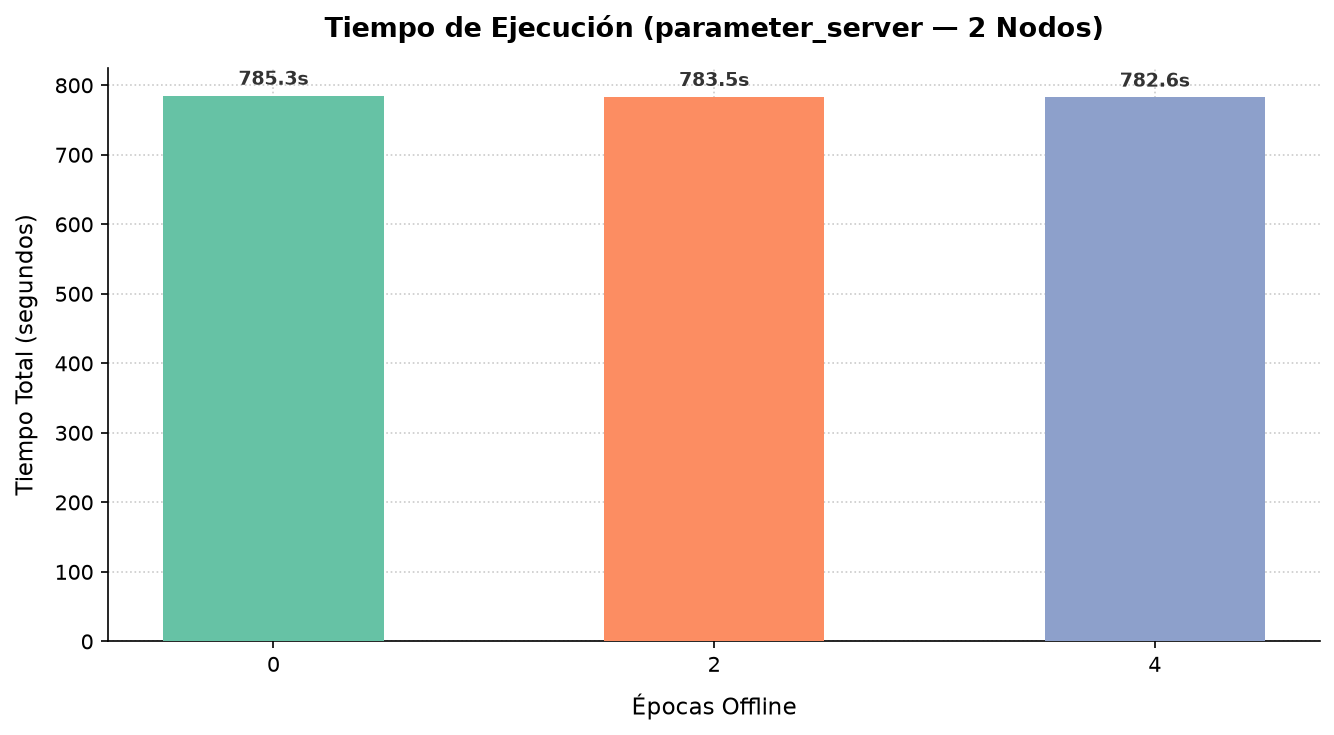

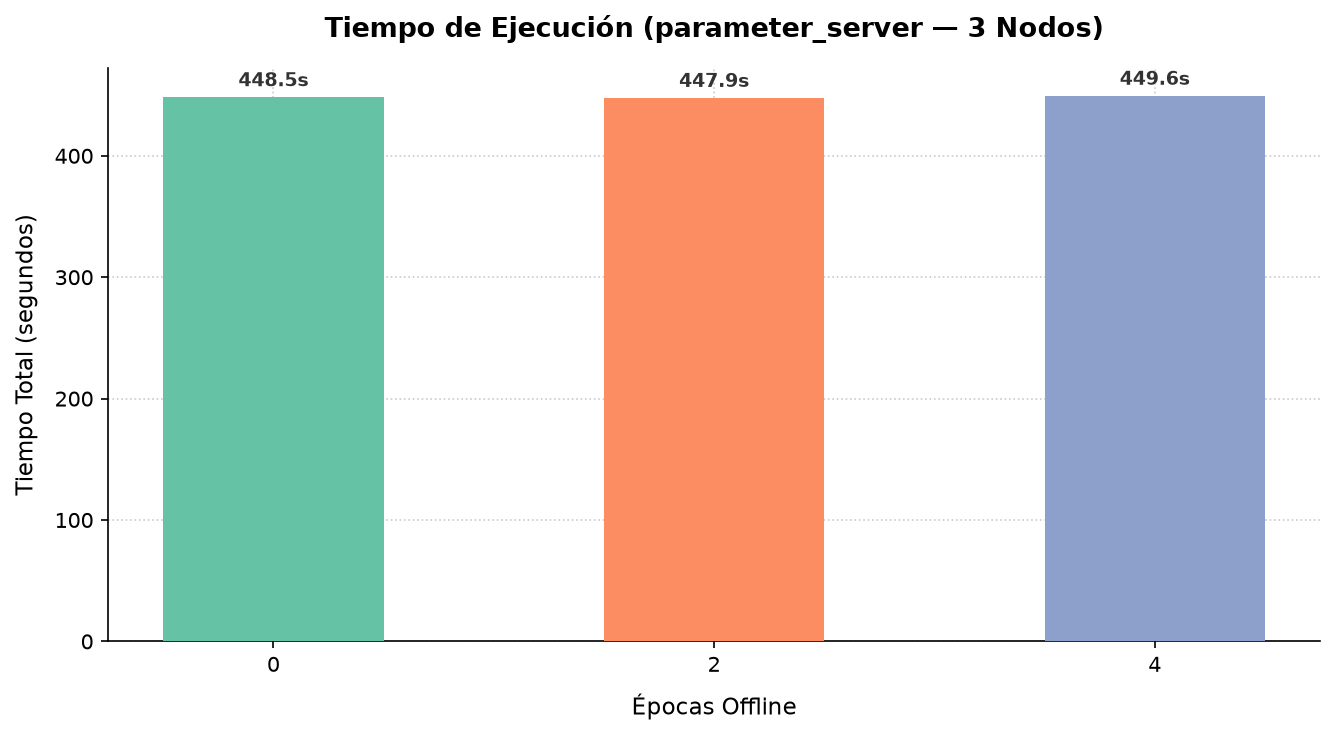

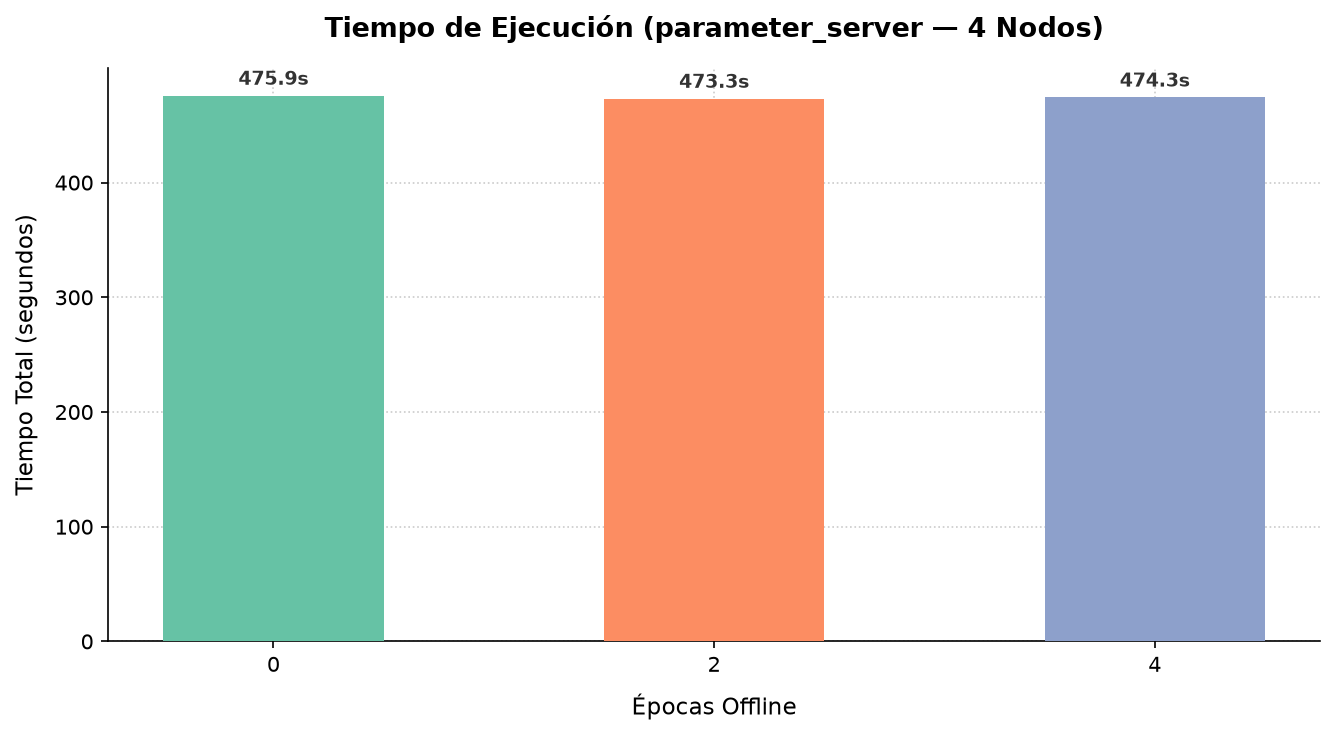

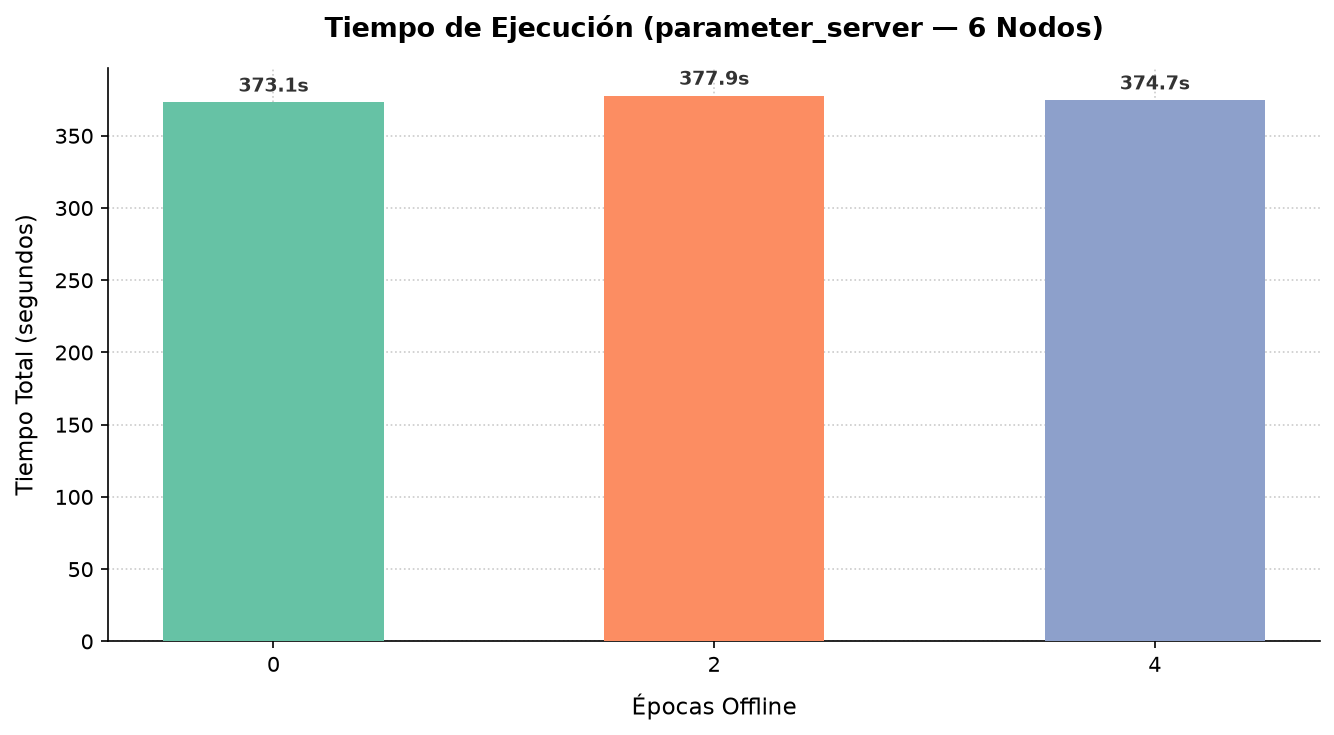

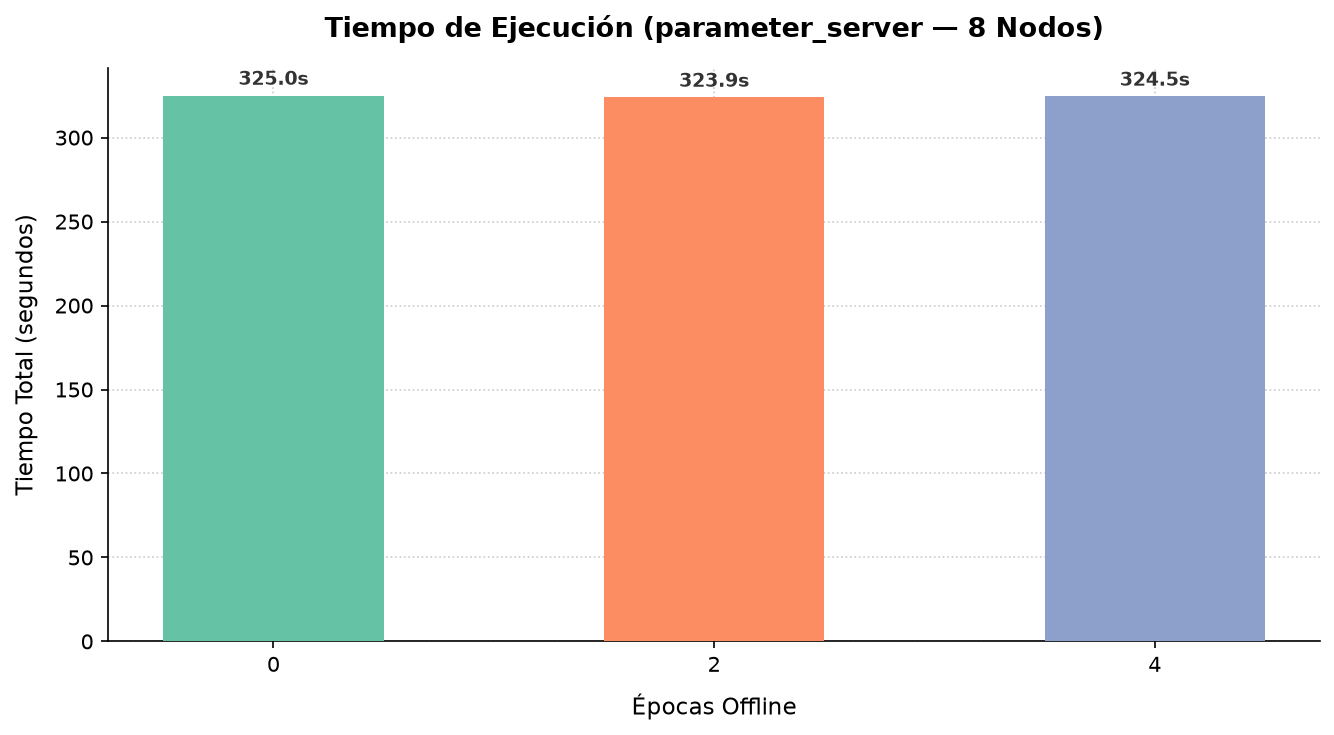

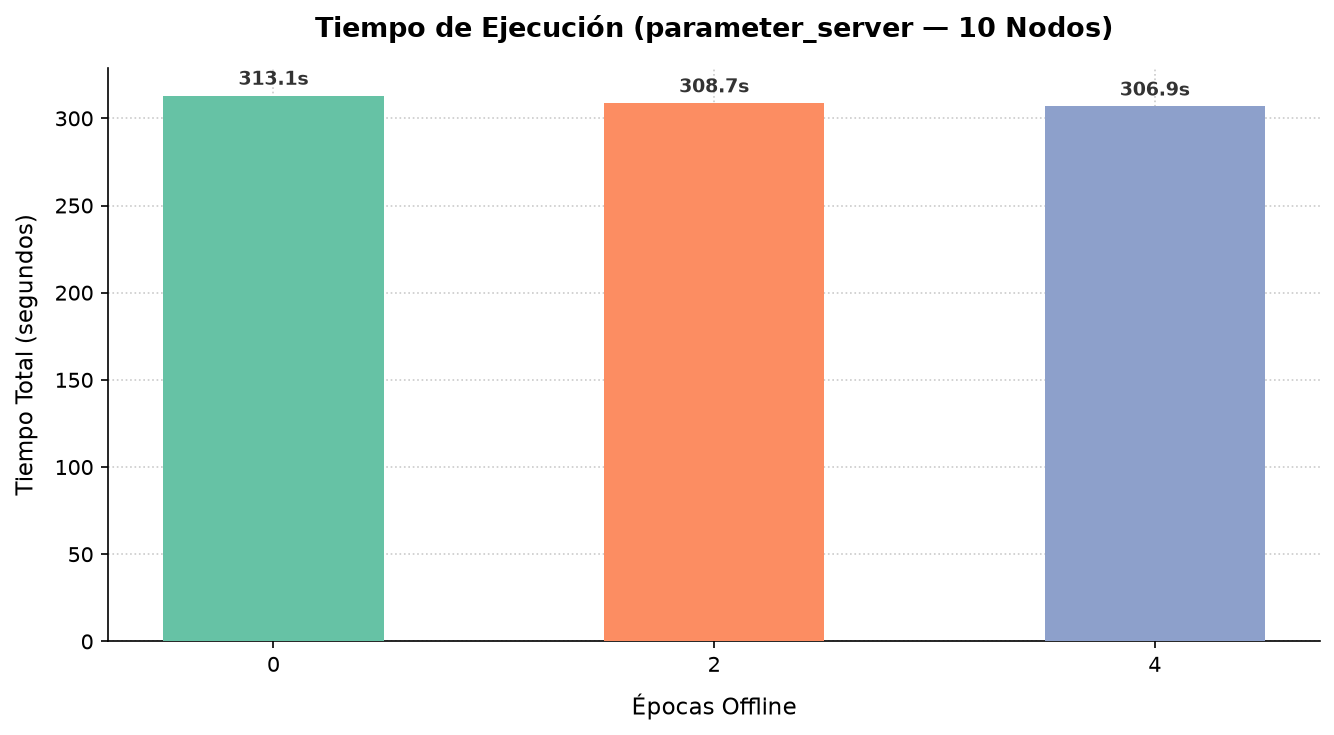

In [5]:
from itertools import product

import matplotlib.pyplot as plt


for algorithm, nodes in product(ALGORITHMS, NODES):
    fig, ax = plt.subplots(figsize=(9, 5))

    x_labels = []
    bar_values = []
    bar_colors = []
    
    for i, offline_epochs in enumerate(OFFLINE_EPOCHS):
        runs = measurements_if(algorithm=algorithm, nodes=nodes, offline_epochs=offline_epochs)
        assert len(runs) == 1
        ms = runs[0]

        x_labels.append(f"{offline_epochs}")
        bar_values.append(ms.secs_taken_avg)
        bar_colors.append(COLORS[i])
    
    bars = ax.bar(
        x_labels, 
        bar_values, 
        color=bar_colors,
        width=0.5,
        zorder=3
    )

    ax.set_title(f"Tiempo de Ejecución ({algorithm} — {nodes} Nodos)", fontsize=13, pad=15, weight='bold')
    ax.set_xlabel("Épocas Offline", fontsize=11, labelpad=8)
    ax.set_ylabel("Tiempo Total (segundos)", fontsize=11, labelpad=8)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.1f}s',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center', 
            va='bottom', 
            fontsize=9, 
            weight='bold',
            color='#333333'
        )

    save_and_plot(f"{algorithm}-{nodes}", "execution_time_per_offline_epoch")


## Pérdida durante el entrenamiento para distintas cantidades de Épocas Offline

Gráficos que muestran como evolucionaron los entrenamientos en los distintos escenarios con algoritmos y cantidades de nodos distintos.

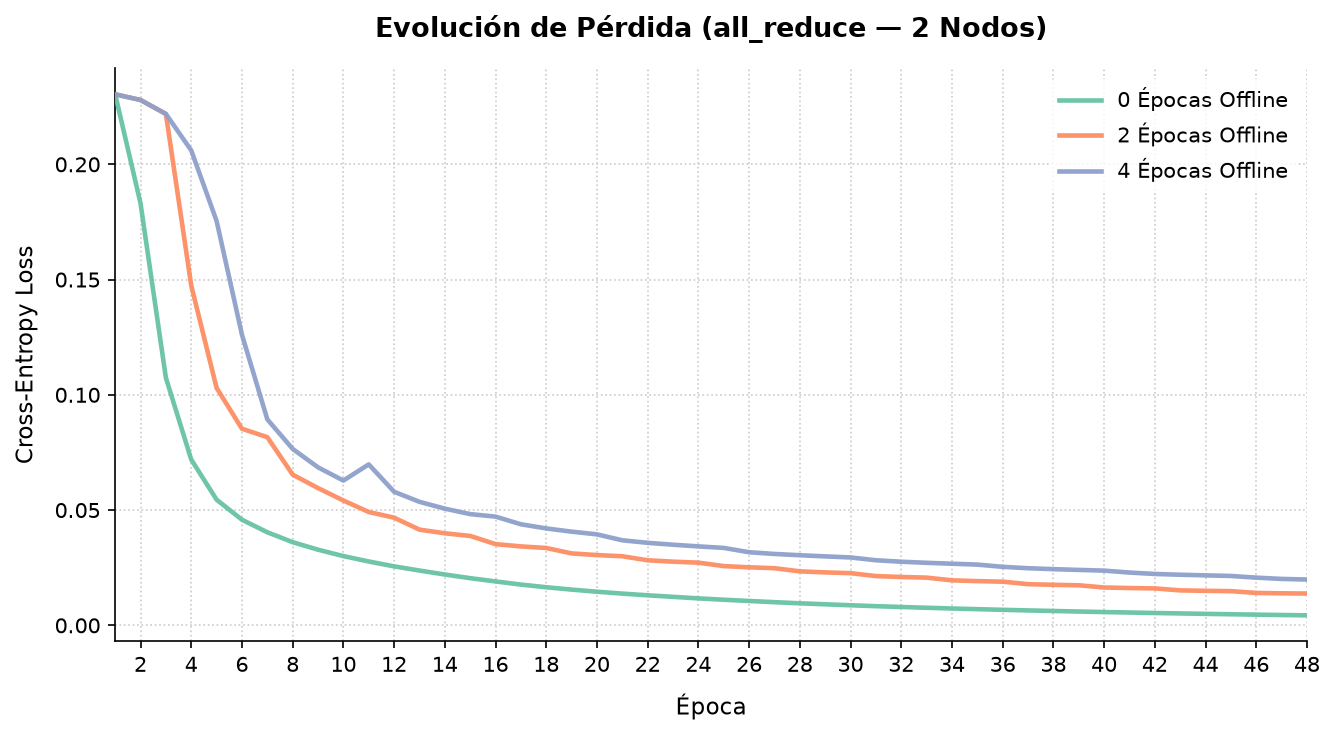

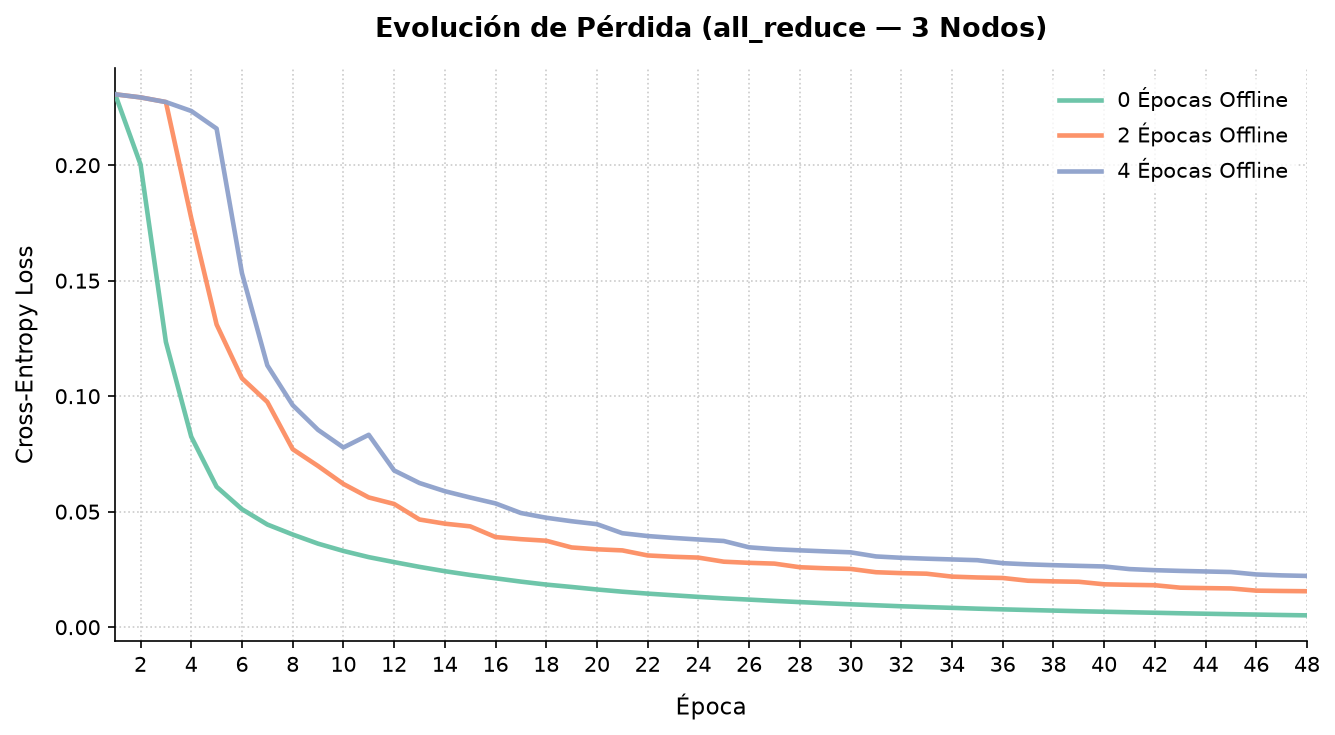

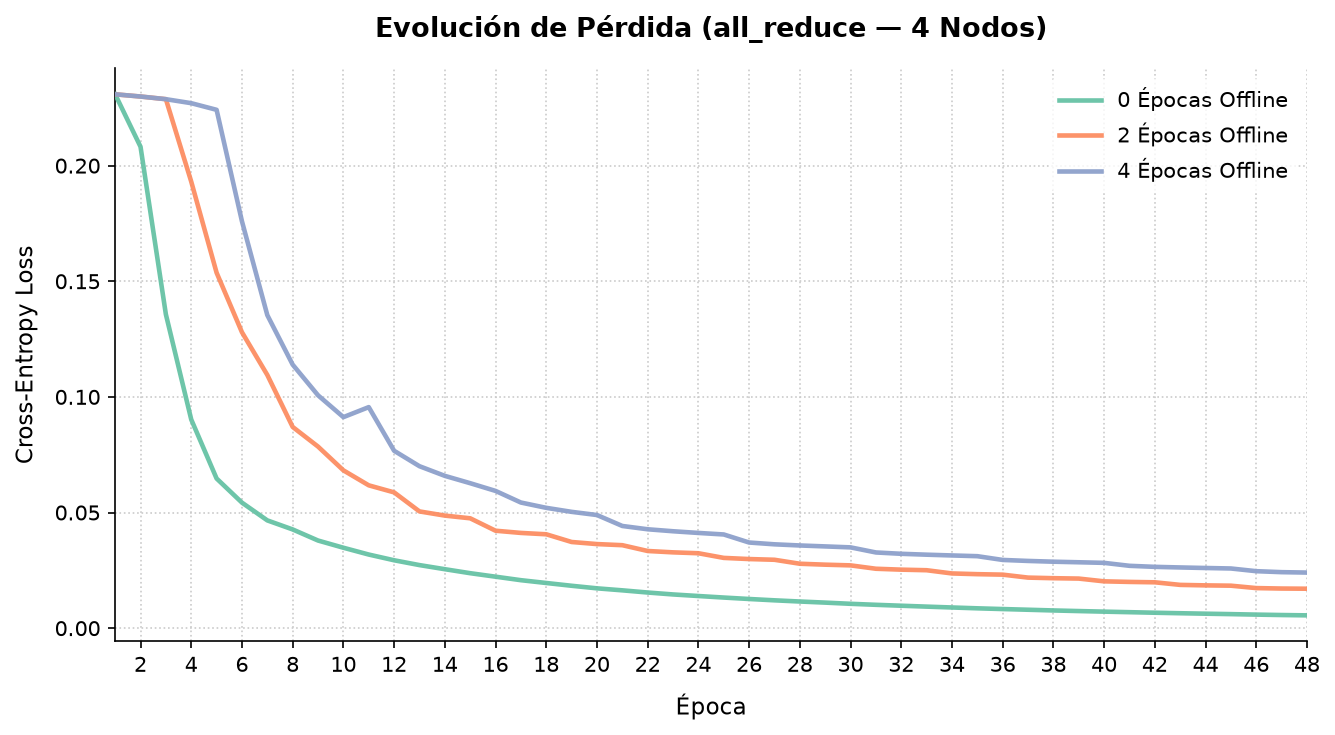

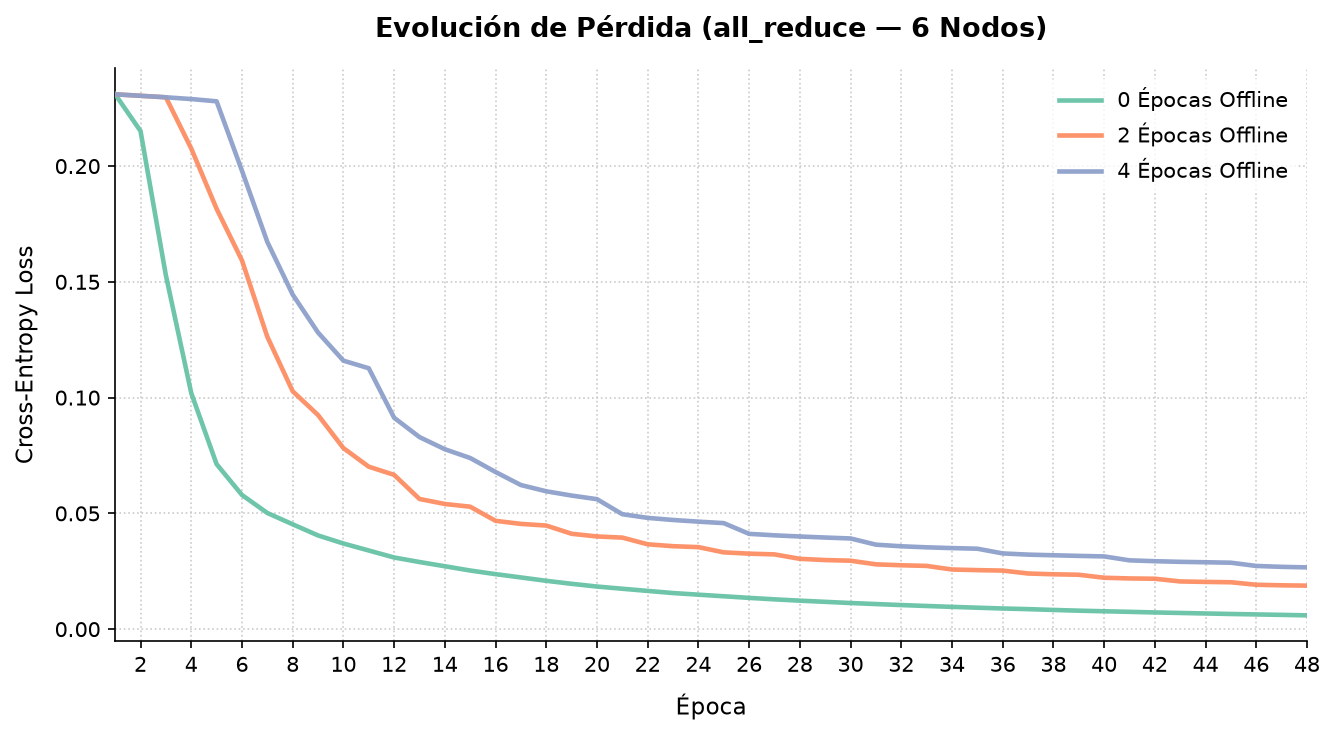

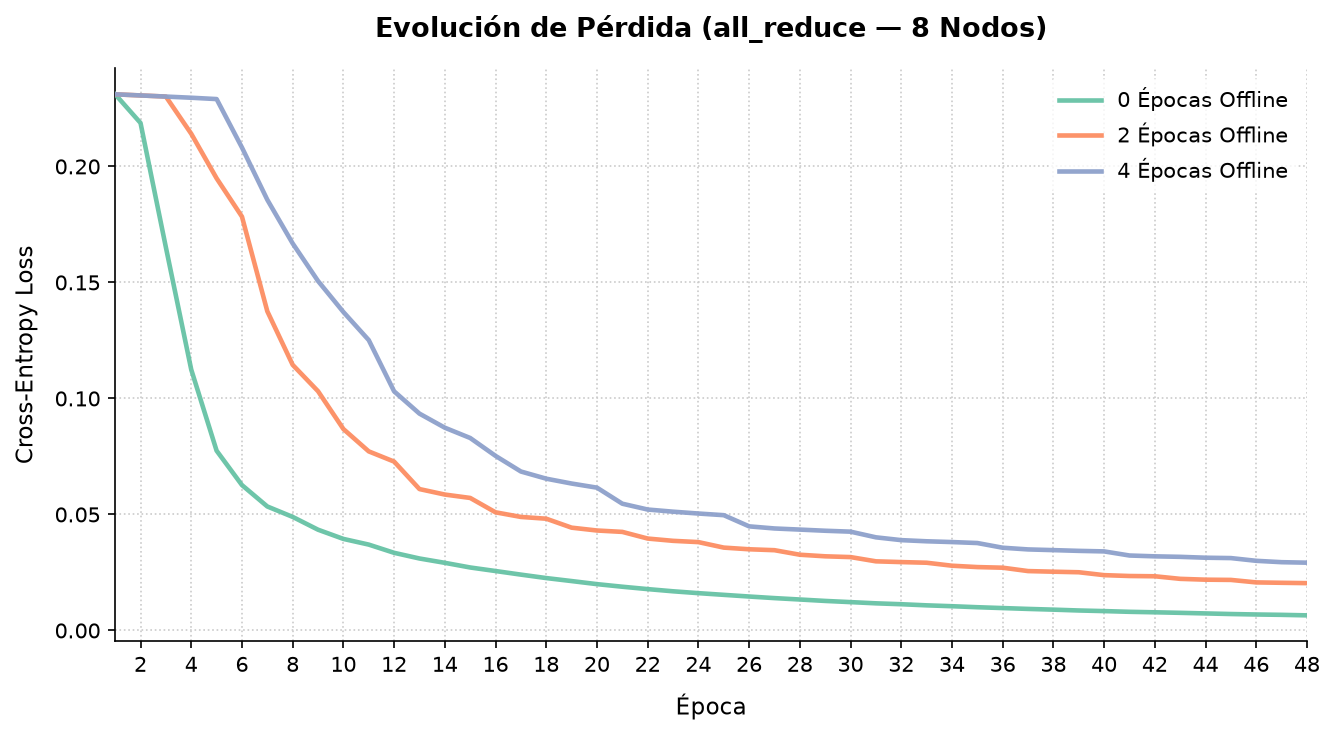

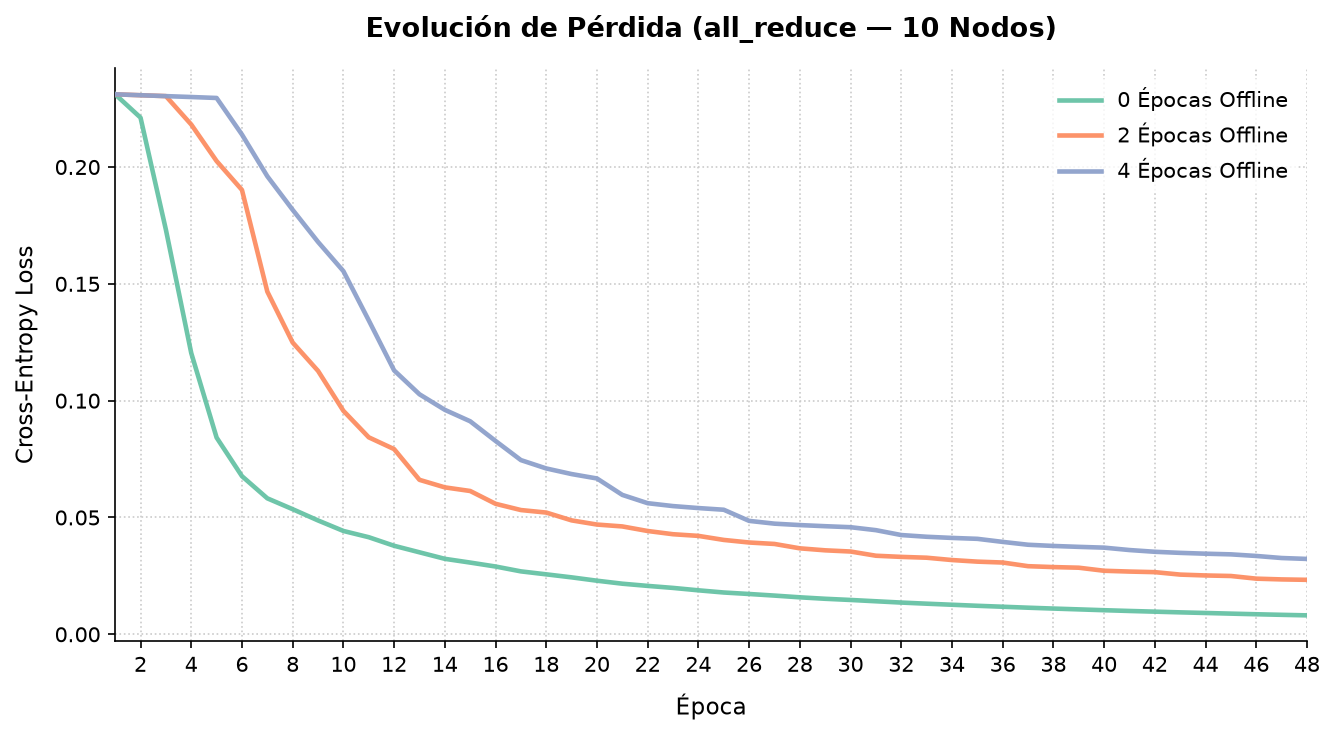

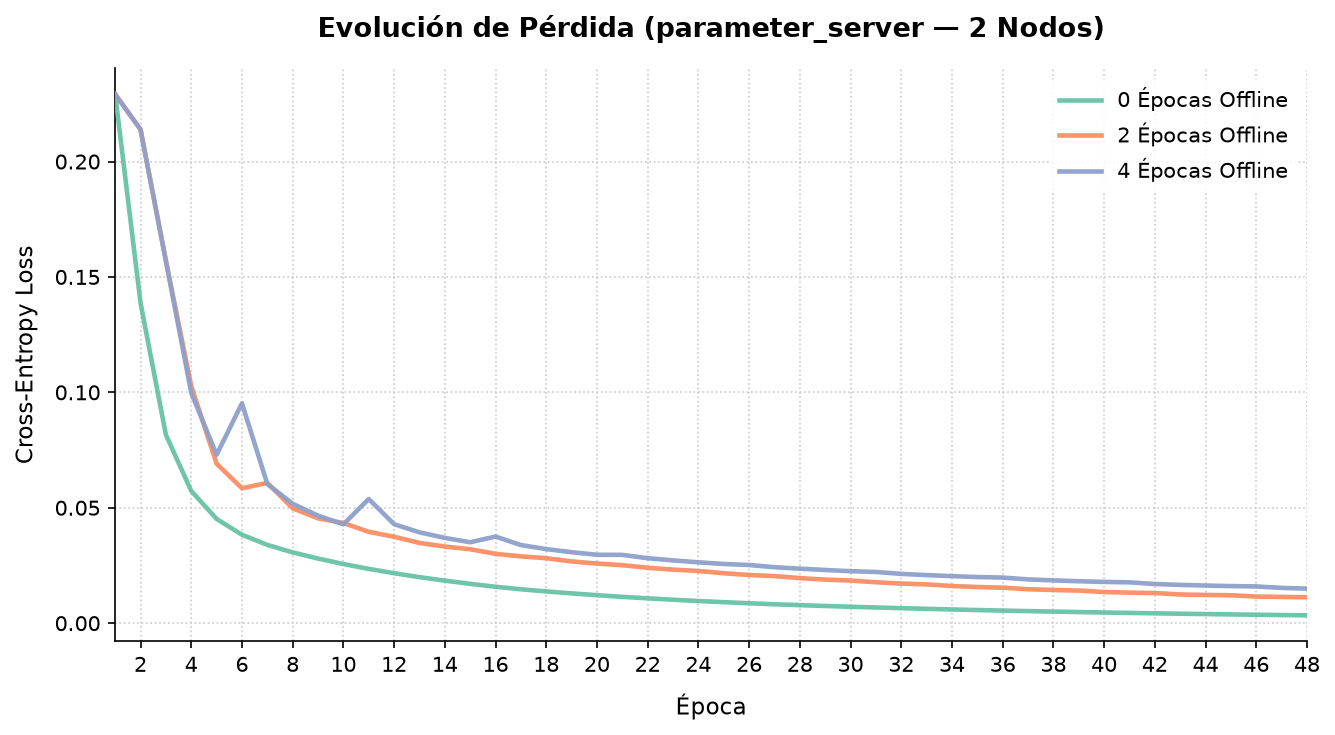

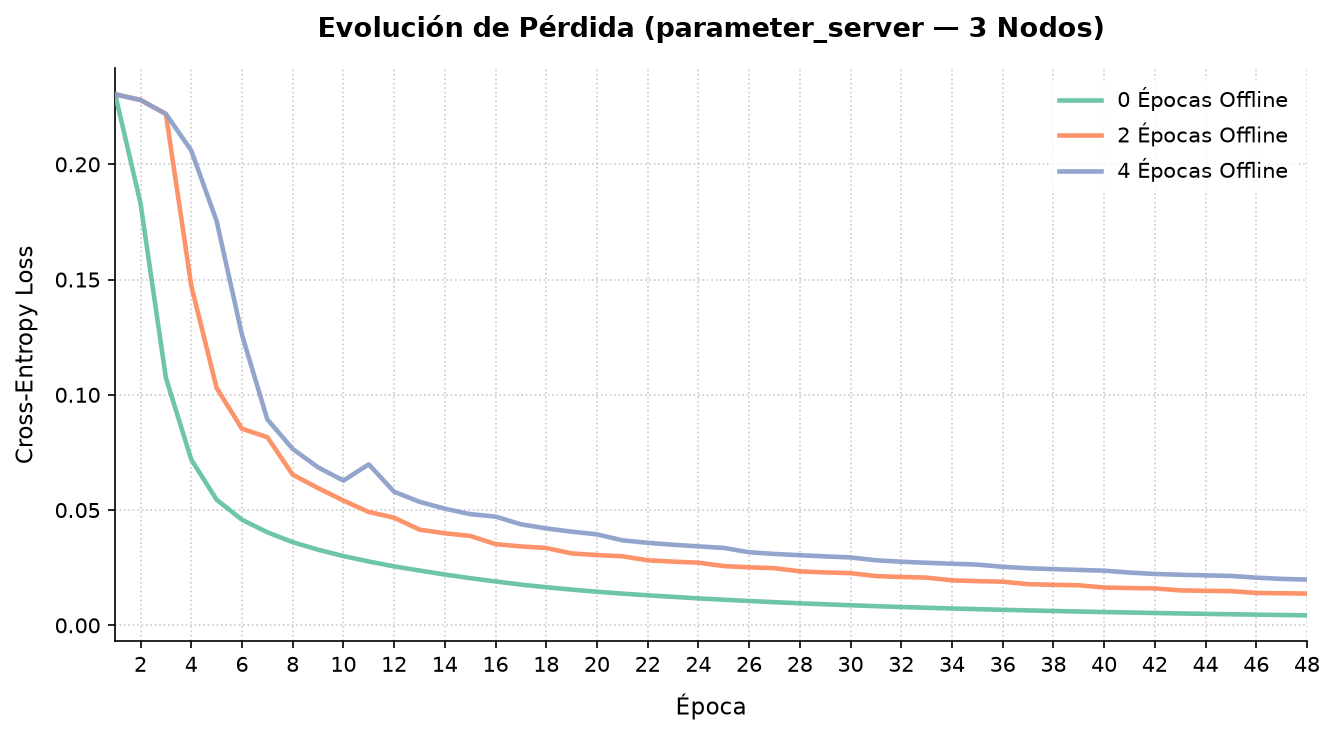

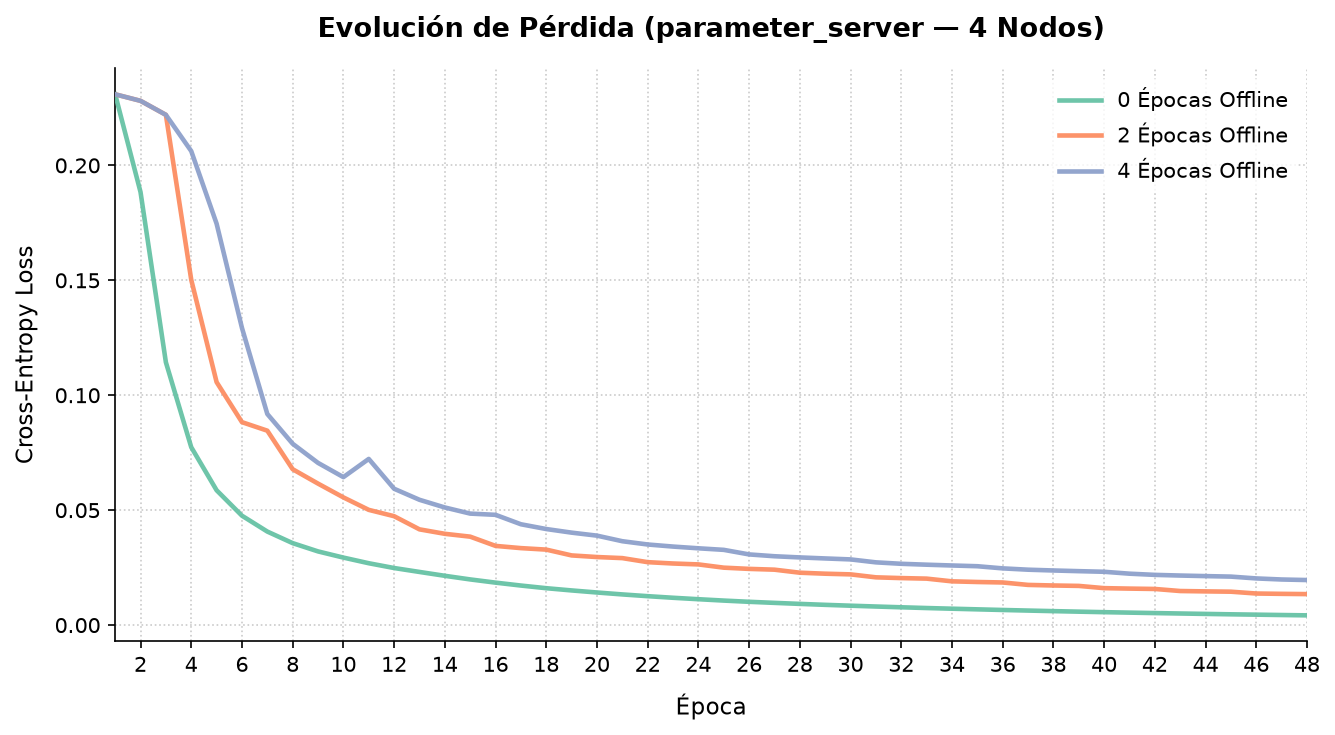

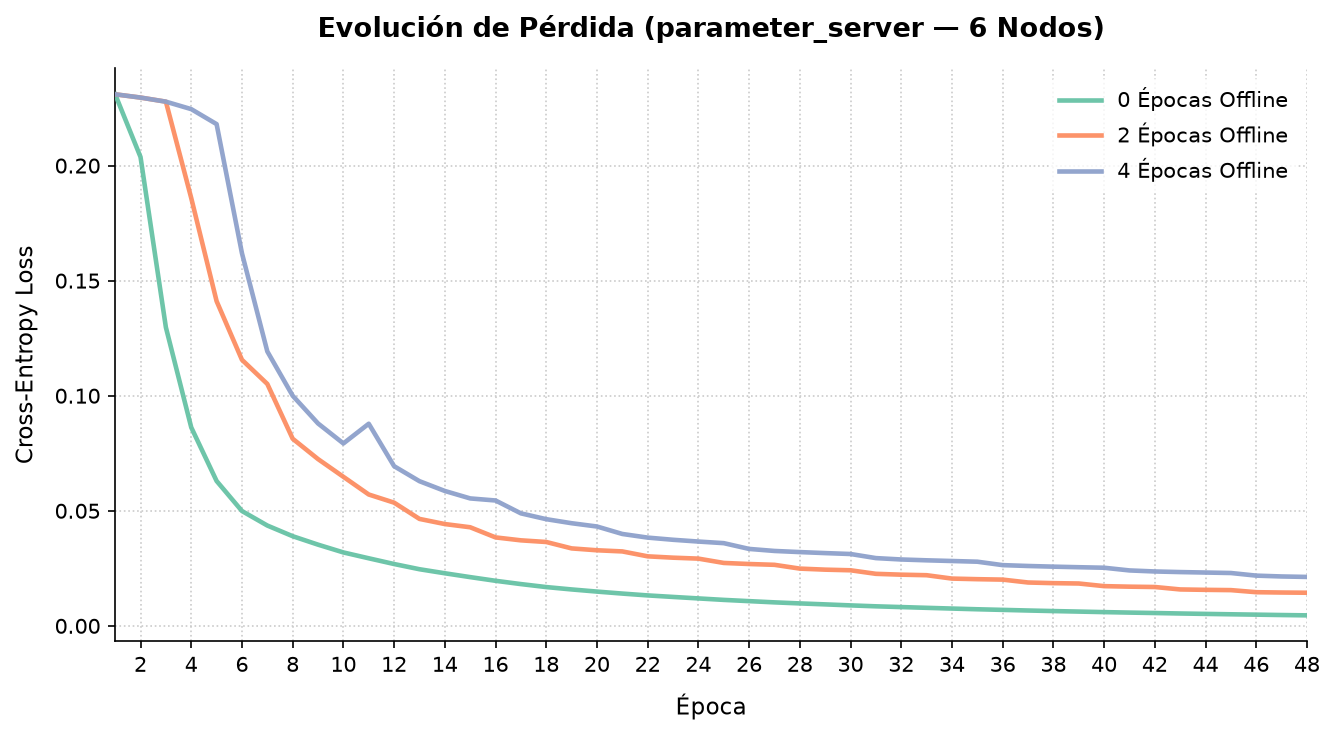

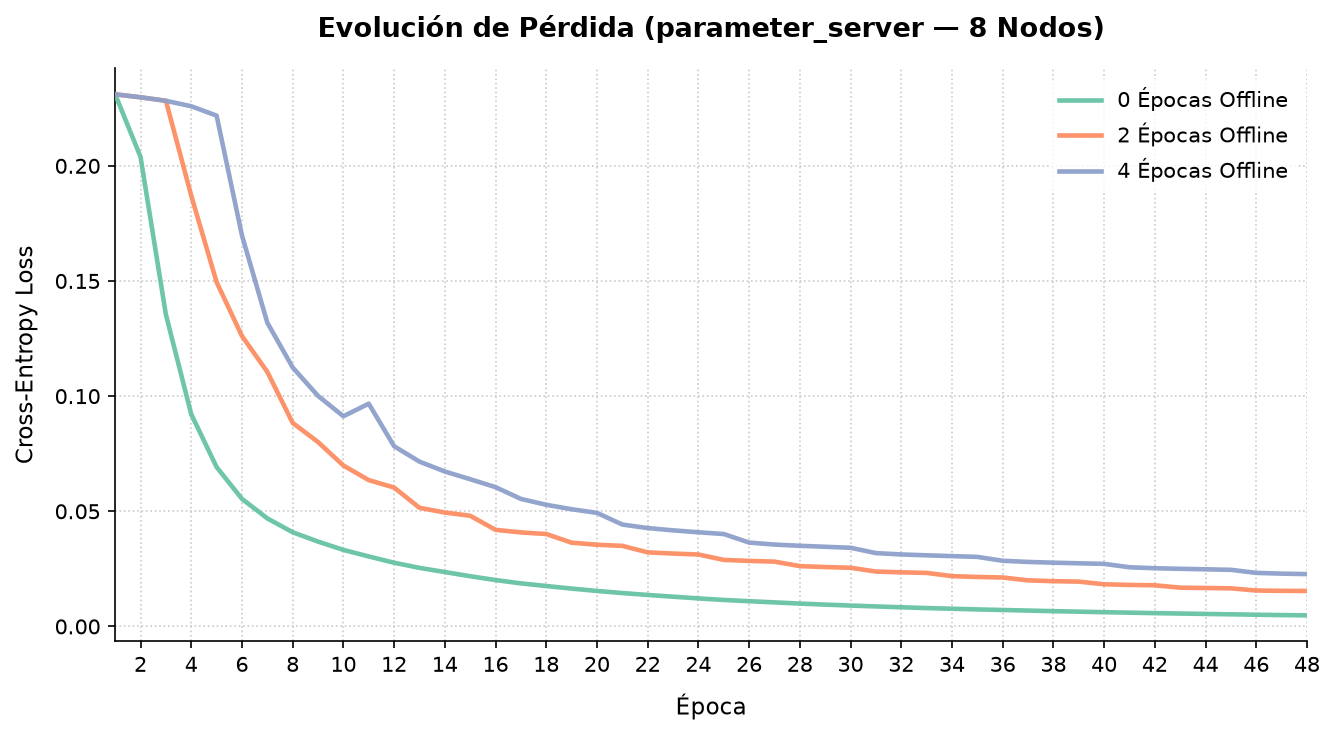

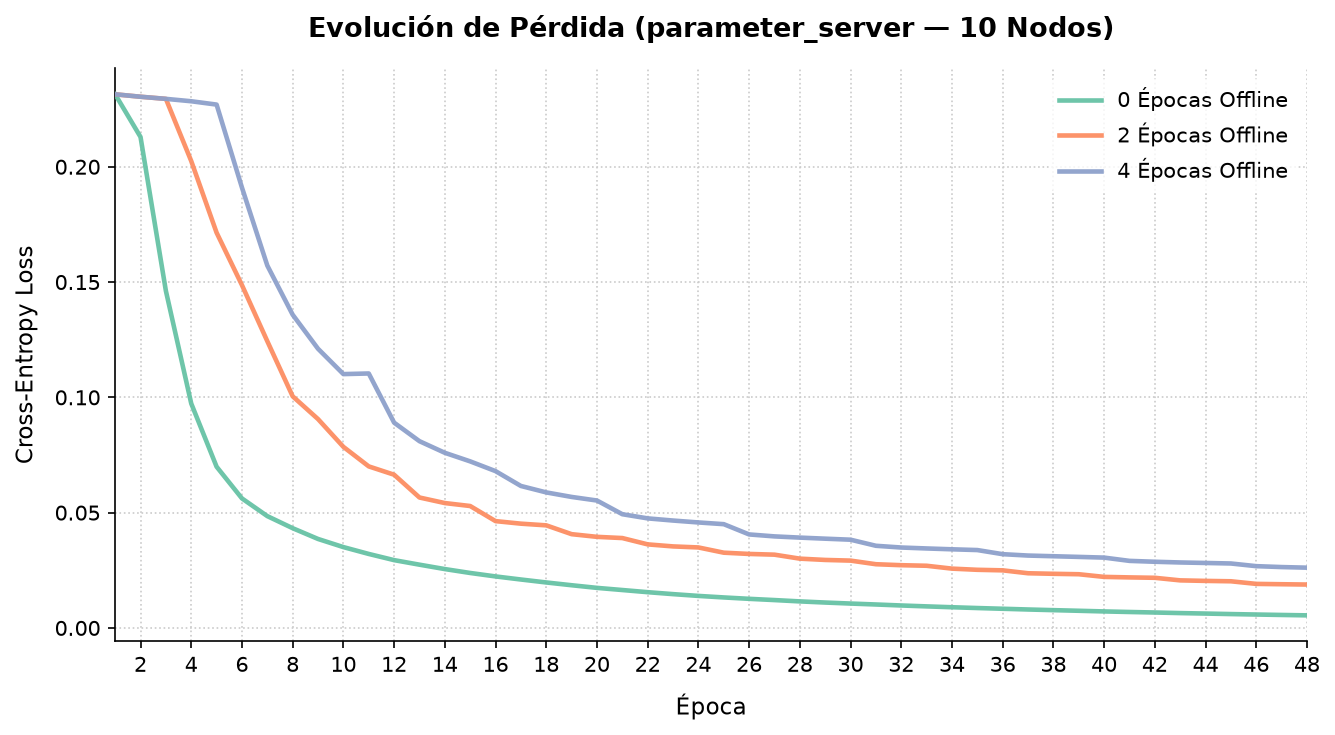

In [6]:
from itertools import product

import matplotlib.pyplot as plt
from matplotlib import ticker


for algorithm, nodes in product(ALGORITHMS, NODES):
    fig, ax = plt.subplots(figsize=(9, 5))
    
    for i, offline_epochs in enumerate(OFFLINE_EPOCHS):
        runs = measurements_if(algorithm=algorithm, nodes=nodes, offline_epochs=offline_epochs)
        assert len(runs) == 1
        ms = runs[0]
        
        ax.plot(
            range(1, len(ms.loss_history_avgs) + 1),
            ms.loss_history_avgs,
            label=f"{offline_epochs} Épocas Offline", 
            color=COLORS[i],
            linewidth=2.2,
            alpha=0.95,
            zorder=3
        )

    ax.set_title(f"Evolución de Pérdida ({algorithm} — {nodes} Nodos)", fontsize=13, pad=15, weight='bold')
    ax.set_xlabel("Época", fontsize=11, labelpad=8)
    ax.set_ylabel("Cross-Entropy Loss", fontsize=11, labelpad=8)

    ax.set_xlim(1, 48)
    ax.grid(True, linestyle=":", color="#CBCBCB", linewidth=0.8, zorder=1)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))

    ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper right')

    save_and_plot(f"{algorithm}-{nodes}", "loss_history_per_offline_epoch")
